# 1. packages

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import pingouin as pg
import scikit_posthocs as sp
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from wordfreq import zipf_frequency
from statsmodels.stats.multitest import multipletests

# 2. constants

In [2]:
FILE = "data/story_word_template.xlsx"
OUT = "results/distortion_surface_controls"
os.makedirs(OUT, exist_ok=True)

STORY = "Story"
VERSION = "Story_Version"
INDEX = "WordIndex"
WORD = "Word"
CONDITION_ORDER = ["Original", "CD", "RD"]

MODEL_NAME = "Qwen/Qwen3-4B-Base"
MODEL_LABEL = "Qwen3-4B-Base"
MAX_CONTEXT_TOKENS = 4096
RANDOM_SEED = 42
ALPHA = 0.05

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not available")

DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
).to(DEVICE).eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

# 3. read and validate stimulus data

In [3]:
template = pd.read_excel(FILE)

required = [STORY, VERSION, INDEX, WORD]
missing = [column for column in required if column not in template.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

template = template[required].dropna().copy()
template[STORY] = template[STORY].astype(str).str.strip()
template[VERSION] = template[VERSION].astype(str).str.strip()
template[WORD] = template[WORD].astype(str).str.strip()
template[INDEX] = pd.to_numeric(template[INDEX], errors="raise").astype(int)
template = template[template[VERSION].isin(CONDITION_ORDER)].copy()

duplicates = template.duplicated([STORY, VERSION, INDEX], keep=False)
if duplicates.any():
    print(template.loc[duplicates].sort_values([STORY, VERSION, INDEX]))
    raise ValueError("Duplicate Story × Story_Version × WordIndex rows found")

condition_counts = template.groupby(STORY)[VERSION].nunique()
complete_stories = condition_counts[condition_counts == 3].index
incomplete_stories = condition_counts[condition_counts != 3]

if len(incomplete_stories) > 0:
    print("Incomplete stories:")
    print(incomplete_stories)

template = template[template[STORY].isin(complete_stories)].copy()
template = template.sort_values([STORY, VERSION, INDEX]).reset_index(drop=True)

stimulus_counts = template.groupby([STORY, VERSION]).size().unstack(VERSION)
stimulus_counts = stimulus_counts.reindex(columns=CONDITION_ORDER)

print("Complete stories:", len(complete_stories))
print("\nRows by condition:")
print(template.groupby(VERSION).size().reindex(CONDITION_ORDER))
print("\nWords per story and condition:")
print(stimulus_counts)
print("\nWord-count summary:")
print(stimulus_counts.describe().round(2))

Complete stories: 21

Rows by condition:
Story_Version
Original    1989
CD          1991
RD          1989
dtype: int64

Words per story and condition:
Story_Version  Original   CD   RD
Story                            
Story1              103  103  103
Story10             103  103  103
Story11             114  114  114
Story12              73   73   73
Story13             102  102  102
Story14             116  116  116
Story15              62   62   62
Story16              89   89   89
Story17              84   84   84
Story18              95   95   95
Story19             107  107  107
Story2              101  101  101
Story20              83   83   83
Story21              74   74   74
Story3              121  121  121
Story4               86   87   86
Story5               83   84   83
Story6               65   65   65
Story7               95   95   95
Story8              114  114  114
Story9              119  119  119

Word-count summary:
Story_Version  Original      CD      RD
count 

# 4. calculate story-level lexical frequency and word length

In [4]:
def extract_lexical_tokens(words):
    text = " ".join(words.astype(str)).lower().replace("’", "'").replace("‘", "'")
    return re.findall(r"[a-z]+(?:'[a-z]+)*", text)

In [5]:
surface_rows = []
for (story, version), dat in template.groupby([STORY, VERSION], sort=False):
    dat = dat.sort_values(INDEX)
    tokens = extract_lexical_tokens(dat[WORD])
    frequencies = np.array([zipf_frequency(token, "en") for token in tokens], dtype=float)
    lengths = np.array([sum(character.isalpha() for character in token) for token in tokens], dtype=float)
    surface_rows.append({
        STORY: story,
        VERSION: version,
        "MeanZipfFrequency": frequencies.mean(),
        "MedianZipfFrequency": np.median(frequencies),
        "MeanWordLength": lengths.mean(),
        "WordCount": len(tokens),
        "OOVRate": np.mean(frequencies == 0),
    })

surface = pd.DataFrame(surface_rows)
surface[VERSION] = pd.Categorical(surface[VERSION], categories=CONDITION_ORDER, ordered=True)
surface = surface.sort_values([STORY, VERSION]).reset_index(drop=True)

print(surface.head())
print("\nRows:", len(surface))
print("\nDescriptive statistics:")
print(surface.groupby(VERSION, observed=False)[["MeanZipfFrequency", "MeanWordLength", "WordCount", "OOVRate"]].agg(["mean", "std"]).round(3))

     Story Story_Version  MeanZipfFrequency  MedianZipfFrequency  \
0   Story1      Original           5.430192                5.280   
1   Story1            CD           5.423077                5.165   
2   Story1            RD           5.398462                5.280   
3  Story10      Original           5.733689                6.300   
4  Story10            CD           5.747379                6.300   

   MeanWordLength  WordCount   OOVRate  
0        4.355769        104  0.019231  
1        4.375000        104  0.019231  
2        4.365385        104  0.019231  
3        3.970874        103  0.000000  
4        3.980583        103  0.000000  

Rows: 63

Descriptive statistics:
              MeanZipfFrequency        MeanWordLength        WordCount  \
                           mean    std           mean    std      mean   
Story_Version                                                            
Original                  5.819  0.129          4.155  0.219    94.857   
CD            

# 5. calculate whole-story perplexity

In [6]:
def story_perplexity(words):
    text = " ".join(words.astype(str))
    input_ids = tokenizer(text, add_special_tokens=False, return_tensors="pt")["input_ids"]

    if input_ids.shape[1] > MAX_CONTEXT_TOKENS:
        raise ValueError(f"Story has {input_ids.shape[1]} tokens, exceeding the {MAX_CONTEXT_TOKENS}-token limit")

    input_ids = input_ids.to(DEVICE)
    with torch.inference_mode():
        loss = model(input_ids=input_ids, labels=input_ids, use_cache=False).loss.float().item()

    scored_tokens = input_ids.shape[1] - 1
    return loss, math.exp(loss), scored_tokens

In [7]:
ppl_rows = []
groups = template.groupby([STORY, VERSION], sort=False)
for (story, version), dat in tqdm(groups, total=groups.ngroups, desc="Whole-story PPL"):
    mean_nll, perplexity, token_count = story_perplexity(dat.sort_values(INDEX)[WORD])
    ppl_rows.append({
        STORY: story, VERSION: version, "MeanNLL": mean_nll, "Perplexity": perplexity, "ModelTokenCount": token_count
    })

ppl = pd.DataFrame(ppl_rows)

Whole-story PPL:   0%|          | 0/63 [00:00<?, ?it/s]

In [8]:
surface = surface.merge(ppl, on=[STORY, VERSION], how="left", validate="one_to_one")
surface.to_csv(os.path.join(OUT, "story_surface_features.csv"), index=False)

print(surface.groupby(VERSION, observed=False)[[
    "Perplexity", "MeanZipfFrequency", "MeanWordLength", "WordCount"
]].agg(["mean", "std"]).round(3))

              Perplexity        MeanZipfFrequency        MeanWordLength  \
                    mean    std              mean    std           mean   
Story_Version                                                             
CD                13.019  3.439             5.821  0.133          4.162   
Original           9.490  2.816             5.819  0.129          4.155   
RD                13.794  4.088             5.799  0.133          4.164   

                     WordCount          
                 std      mean     std  
Story_Version                           
CD             0.217    94.952  17.571  
Original       0.219    94.857  17.625  
RD             0.220    94.857  17.625  


# 6. nonparametric paired comparisons

In [13]:
METRICS = {"Perplexity": "Perplexity", "MeanZipfFrequency": "Lexical frequency", "MeanWordLength": "Word length"}
CONTRASTS = [("CD - Original", "CD", "Original"), ("RD - Original", "RD", "Original"), ("CD - RD", "CD", "RD")]
omnibus_rows, pairwise_rows = [], []

for metric, label in METRICS.items():
    dat = surface[[STORY, VERSION, metric]].dropna().copy()
    wide = dat.pivot(index=STORY, columns=VERSION, values=metric).dropna()[CONDITION_ORDER]
    complete = wide.reset_index().melt(id_vars=STORY, value_vars=CONDITION_ORDER, var_name=VERSION, value_name=metric)

    friedman = pg.friedman(data=complete, dv=metric, within=VERSION, subject=STORY, method="chisq").iloc[0]
    omnibus_rows.append({"Metric": metric, "Label": label, "NStories": len(wide), "Q": friedman["Q"], "DF": friedman["ddof1"], "P": friedman["p-unc"], "KendallsW": friedman["W"]})

    posthoc = sp.posthoc_siegel_friedman(wide.to_numpy(), p_adjust="fdr_bh")
    posthoc.index = CONDITION_ORDER
    posthoc.columns = CONDITION_ORDER
    posthoc.to_csv(os.path.join(OUT, f"{metric}_siegel_fdr_matrix.csv"))

    for contrast, first, second in CONTRASTS:
        differences = wide[first] - wide[second]
        pairwise_rows.append({
            "Metric": metric,
            "Label": label,
            "Test": "Siegel-Castellan",
            "Contrast": contrast,
            "NStories": len(wide),
            "MedianDifference": differences.median(),
            "MeanDifference": differences.mean(),
            "P_FDR": posthoc.loc[first, second],
        })

omnibus_results = pd.DataFrame(omnibus_rows)
omnibus_results["P_FDR_AcrossMetrics"] = multipletests(omnibus_results["P"], method="fdr_bh")[1]
pairwise_results = pd.DataFrame(pairwise_rows)

omnibus_results.to_csv(os.path.join(OUT, "surface_friedman_tests.csv"), index=False)
pairwise_results.to_csv(os.path.join(OUT, "surface_siegel_fdr_tests.csv"), index=False)

print("\nFriedman tests:")
print(omnibus_results.round(4).to_string(index=False))
print("\nSiegel-Castellan pairwise comparisons:")
print(pairwise_results.round(4).to_string(index=False))


Friedman tests:
           Metric             Label  NStories      Q  DF      P  KendallsW  P_FDR_AcrossMetrics
       Perplexity        Perplexity        21 34.381   2 0.0000     0.8186               0.0000
MeanZipfFrequency Lexical frequency        21 14.000   2 0.0009     0.3333               0.0014
   MeanWordLength       Word length        21  5.425   2 0.0664     0.1292               0.0664

Siegel-Castellan pairwise comparisons:
           Metric             Label             Test      Contrast  NStories  MedianDifference  MeanDifference  P_FDR
       Perplexity        Perplexity Siegel-Castellan CD - Original        21            3.3561          3.5285 0.0001
       Perplexity        Perplexity Siegel-Castellan RD - Original        21            4.3365          4.3039 0.0000
       Perplexity        Perplexity Siegel-Castellan       CD - RD        21           -0.4692         -0.7754 0.0896
MeanZipfFrequency Lexical frequency Siegel-Castellan CD - Original        21           

# 7. visualize nonparametric surface-control results

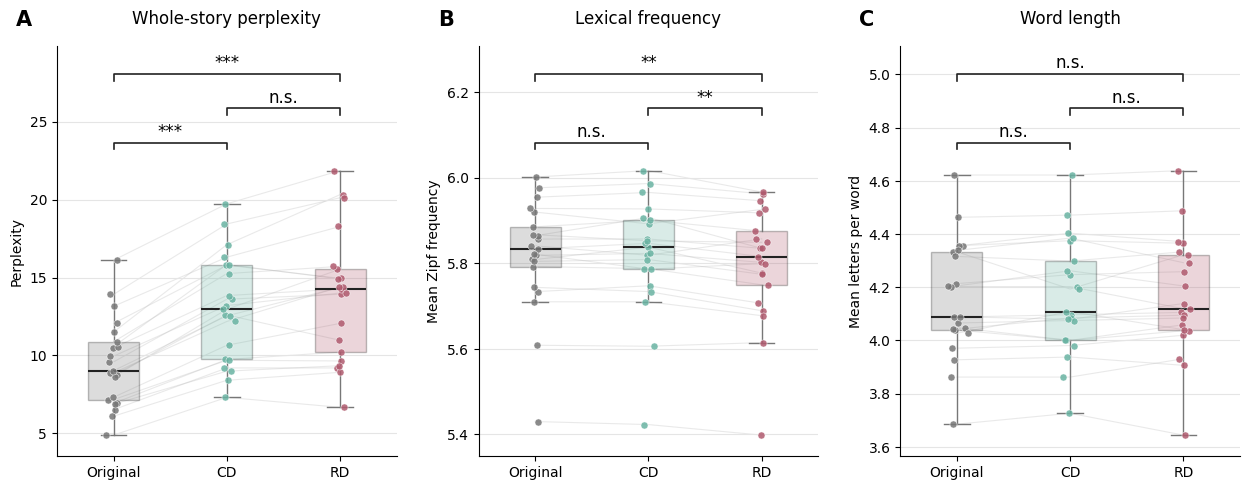

In [16]:
COLORS = {"Original": "#777777", "CD": "#69B3A2", "RD": "#B05A6E"}
PLOT_SPECS = [("Perplexity", "Perplexity", "A", "Whole-story perplexity"), ("MeanZipfFrequency", "Mean Zipf frequency", "B", "Lexical frequency"), ("MeanWordLength", "Mean letters per word", "C", "Word length")]
BRACKETS = [("Original", "CD", "CD - Original"), ("CD", "RD", "CD - RD"), ("Original", "RD", "RD - Original")]
POSITION = {"Original": 0, "CD": 1, "RD": 2}
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(12.6, 5.0))

for ax, (metric, ylabel, panel, title) in zip(axes, PLOT_SPECS):
    wide = surface.pivot(index=STORY, columns=VERSION, values=metric).dropna()[CONDITION_ORDER]
    x = np.arange(3)

    for _, values in wide.iterrows():
        ax.plot(x, values.to_numpy(float), color="#B8B8B8", linewidth=0.8, alpha=0.30, zorder=1)

    boxes = ax.boxplot([wide[condition] for condition in CONDITION_ORDER], positions=x, widths=0.45, patch_artist=True, showfliers=False, medianprops={"color": "#222222", "linewidth": 1.5}, whiskerprops={"color": "#777777"}, capprops={"color": "#777777"})
    for box, condition in zip(boxes["boxes"], CONDITION_ORDER):
        box.set_facecolor(COLORS[condition])
        box.set_alpha(0.25)

    for position, condition in enumerate(CONDITION_ORDER):
        jitter = rng.normal(0, 0.035, len(wide))
        ax.scatter(position + jitter, wide[condition], s=26, color=COLORS[condition], edgecolor="white", linewidth=0.4, alpha=0.85, zorder=3)

    data_min, data_max = wide.min().min(), wide.max().max()
    span = data_max - data_min
    if span == 0: span = max(abs(data_max), 1.0)

    bracket_base = data_max + 0.08 * span
    bracket_step = 0.13 * span
    bracket_cap = 0.025 * span

    for level, (first, second, contrast) in enumerate(BRACKETS):
        p_value = pairwise_results.loc[(pairwise_results["Metric"] == metric) & (pairwise_results["Contrast"] == contrast), "P_FDR"].iloc[0]
        significance = "***" if p_value < .001 else "**" if p_value < .01 else "*" if p_value < .05 else "n.s."
        left, right = POSITION[first], POSITION[second]
        y = bracket_base + level * bracket_step
        ax.plot([left, left, right, right], [y, y + bracket_cap, y + bracket_cap, y], color="#222222", linewidth=1.2, clip_on=False)
        ax.text((left + right) / 2, y + bracket_cap + 0.008 * span, significance, ha="center", va="bottom", fontsize=12)

    ax.set_ylim(data_min - 0.08 * span, bracket_base + 2 * bracket_step + 0.13 * span)
    ax.set_xticks(x, CONDITION_ORDER)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, pad=16)
    ax.text(-0.12, 1.05, panel, transform=ax.transAxes, fontsize=15, fontweight="bold")
    ax.grid(axis="y", color="#E5E5E5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout(w_pad=2.2)
fig.savefig(os.path.join(OUT, "distortion_surface_controls.svg"), format="svg", bbox_inches="tight")
plt.show()